In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid') # Set the style for all plots
print("All imports successful!")

All imports successful!


In [2]:
# Cell 2 — Load data
df = pd.read_csv('../data/raw/daily_88101_2025.csv')

print("Shape:", df.shape) # (466760, 29)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (466760, 29)

Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

First look:


,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
1,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
2,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
3,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
4,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,NaN,209,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29


In [3]:
# Cell 3 — Data types and basic info
df.info() #checking data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 466760 entries, 0 to 466759
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   State Code           466760 non-null  int64  
 1   County Code          466760 non-null  int64  
 2   Site Num             466760 non-null  int64  
 3   Parameter Code       466760 non-null  int64  
 4   POC                  466760 non-null  int64  
 5   Latitude             466760 non-null  float64
 6   Longitude            466760 non-null  float64
 7   Datum                466760 non-null  str    
 8   Parameter Name       466760 non-null  str    
 9   Sample Duration      466760 non-null  str    
 10  Pollutant Standard   251074 non-null  str    
 11  Date Local           466760 non-null  str    
 12  Units of Measure     466760 non-null  str    
 13  Event Type           19759 non-null   str    
 14  Observation Count    466760 non-null  int64  
 15  Observation Percent  466760 

In [4]:
# Cell 4 — Summary statistics
df.describe()

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Observation Count,Observation Percent,Arithmetic Mean,1st Max Value,1st Max Hour,AQI,Method Code
count,466760.000000,466760.000000,466760.000000,466760.0,466760.000000,466760.000000,466760.000000,466760.000000,466760.000000,466760.000000,466760.000000,466760.000000,251074.000000,466760.000000
mean,29.000538,76.848511,692.858210,88101.0,2.934242,38.226376,-94.295894,11.494747,99.453280,7.381640,10.817963,5.302297,36.506771,422.060828
std,15.948845,91.420762,1552.410128,0.0,1.491478,5.501133,17.252394,11.371749,4.404479,6.008974,14.998409,7.745204,18.355526,227.022597
min,1.000000,1.000000,1.000000,88101.0,1.000000,18.009558,-158.088613,1.000000,4.000000,-5.733333,-5.400000,0.000000,0.000000,116.000000
25%,16.000000,21.000000,7.000000,88101.0,3.000000,34.955566,-107.691767,1.000000,100.000000,4.100000,5.200000,0.000000,23.000000,182.000000
50%,30.000000,53.000000,24.000000,88101.0,3.000000,39.327830,-88.996896,1.000000,100.000000,6.141667,8.100000,0.000000,34.000000,636.000000
75%,42.000000,103.000000,1001.000000,88101.0,3.000000,41.606662,-81.365556,24.000000,100.000000,9.100000,12.800000,9.000000,51.000000,636.000000
max,80.000000,810.000000,9997.000000,88101.0,23.000000,64.845930,-65.618888,24.000000,100.000000,288.500000,1353.900000,23.000000,426.000000,738.000000


In [5]:
# Cell 5 — Select key columns for time series
cols_keep = [
    'Date of Last Change', 
    'Site Num',
    'Local Site Name',
    'State Name', 
    'County Name',
    'City Name',
    'Latitude', 
    'Longitude',
    'Arithmetic Mean',   # this is our AQI PM2.5 value
    'Units of Measure',
    'Observation Count',
    'Observation Percent'
]

# Keep only what we need
df = df[cols_keep]
print(df.shape)
df.head()

(466760, 12)


,Date of Last Change,Site Num,Local Site Name,State Name,County Name,City Name,Latitude,Longitude,Arithmetic Mean,Units of Measure,Observation Count,Observation Percent
0,2025-10-29,10,"FAIRHOPE, Alabama",Alabama,Baldwin,Fairhope,30.497478,-87.880258,3.625000,Micrograms/cubic meter (LC),24,100.0
1,2025-10-29,10,"FAIRHOPE, Alabama",Alabama,Baldwin,Fairhope,30.497478,-87.880258,6.791667,Micrograms/cubic meter (LC),24,100.0
2,2025-10-29,10,"FAIRHOPE, Alabama",Alabama,Baldwin,Fairhope,30.497478,-87.880258,9.958333,Micrograms/cubic meter (LC),24,100.0
3,2025-10-29,10,"FAIRHOPE, Alabama",Alabama,Baldwin,Fairhope,30.497478,-87.880258,5.500000,Micrograms/cubic meter (LC),24,100.0
4,2025-10-29,10,"FAIRHOPE, Alabama",Alabama,Baldwin,Fairhope,30.497478,-87.880258,5.500000,Micrograms/cubic meter (LC),24,100.0


In [6]:
# Cell 6 — Parse dates
df.rename(columns={'Date of Last Change': 'Date', 'Site Num': 'Site ID'}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Site ID', 'Date']).reset_index(drop=True)

print("Date range:", df['Date'].min(), "→", df['Date'].max())
print("Unique stations:", df['Site ID'].nunique())
print("Unique states:", df['State Name'].nunique())
print("Unique counties:", df['County Name'].nunique())
print("Unique cities:", df['City Name'].nunique())

Date range: 2025-03-10 00:00:00 → 2025-11-25 00:00:00
Unique stations: 281
Unique states: 53
Unique counties: 525
Unique cities: 693


In [7]:
# Cell 7 — Filter to a manageable subset of states
states_keep = ['California', 'Texas', 'New York', 'Illinois', 'Colorado']

df_filtered = df[df['State Name'].isin(states_keep)].copy()

print("Filtered shape:", df_filtered.shape)
print("\nStations per state:")
print(df_filtered.groupby('State Name')['Site ID'].nunique())

Filtered shape: (108530, 12)

Stations per state:
State Name
California    63
Colorado      19
Illinois      32
New York      23
Texas         48
Name: Site ID, dtype: int64


In [8]:
# Cell 8 — Rename for convenience
df_filtered = df_filtered.rename(columns={'Arithmetic Mean': 'PM25'})

print("PM2.5 stats:")
print(df_filtered['PM25'].describe())
print("\nMissing values:", df_filtered['PM25'].isna().sum())

PM2.5 stats:
count    108530.000000
mean          8.079405
std           6.738920
min          -5.733333
25%           4.300000
50%           6.666667
75%          10.100000
max         288.500000
Name: PM25, dtype: float64

Missing values: 0


In [9]:
# Cell 9 — Rank states by data completeness
state_quality = df.groupby('State Name').apply(
    lambda x: pd.Series({
        'stations'       : x['Site ID'].nunique(),
        'total_records'  : len(x),
        'missing_pct'    : x['Arithmetic Mean'].isna().mean() * 100,
        'avg_pm25'       : x['Arithmetic Mean'].mean(),
        'date_coverage'  : x['Date'].nunique()
    })
).round(2)

state_quality = state_quality.sort_values(['missing_pct', 'stations'], 
                                          ascending=[True, False])

print("States ranked by data completeness (best first):\n")
print(state_quality.to_string())

States ranked by data completeness (best first):

                      stations  total_records  missing_pct  avg_pm25  date_coverage
State Name                                                                         
California                63.0        38982.0          0.0      7.39           46.0
Texas                     48.0        24803.0          0.0      9.92           11.0
Pennsylvania              37.0        22985.0          0.0      7.61            7.0
Illinois                  32.0        19407.0          0.0      9.06            4.0
Florida                   29.0        17415.0          0.0      6.92           12.0
Ohio                      28.0        25429.0          0.0      8.90           11.0
Minnesota                 26.0         4398.0          0.0      5.39            2.0
Indiana                   23.0        18265.0          0.0      8.76            6.0
New York                  23.0        10708.0          0.0      7.54            3.0
Arizona                   

In [10]:
# Cell 10 — Understand the actual data structure
print("Total date range in dataset:")
print(df['Date'].min(), "→", df['Date'].max())

print("\nSample of dates available:")
print(sorted(df['Date'].unique())[:20])

print("\nHow many rows per date (first 10 dates):")
print(df.groupby('Date').size().head(10))

print("\nHow many rows per station per date (sample):")
sample_station = df['Site ID'].iloc[0]
print(df[df['Site ID'] == sample_station][['Date', 'Arithmetic Mean']].head(20))

Total date range in dataset:
2025-03-10 00:00:00 → 2025-11-25 00:00:00

Sample of dates available:
[Timestamp('2025-03-10 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-04-28 00:00:00'), Timestamp('2025-04-29 00:00:00'), Timestamp('2025-05-20 00:00:00'), Timestamp('2025-05-23 00:00:00'), Timestamp('2025-06-03 00:00:00'), Timestamp('2025-06-10 00:00:00'), Timestamp('2025-06-16 00:00:00'), Timestamp('2025-06-17 00:00:00'), Timestamp('2025-06-18 00:00:00'), Timestamp('2025-06-27 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07-01 00:00:00'), Timestamp('2025-07-09 00:00:00'), Timestamp('2025-07-10 00:00:00'), Timestamp('2025-07-16 00:00:00'), Timestamp('2025-07-18 00:00:00'), Timestamp('2025-07-23 00:00:00'), Timestamp('2025-08-03 00:00:00')]

How many rows per date (first 10 dates):
Date
2025-03-10     11
2025-03-31      3
2025-04-28    202
2025-04-29     16
2025-05-20     43
2025-05-23     17
2025-06-03      4
2025-06-10    160
2025-06-16     47
2025-06-17 

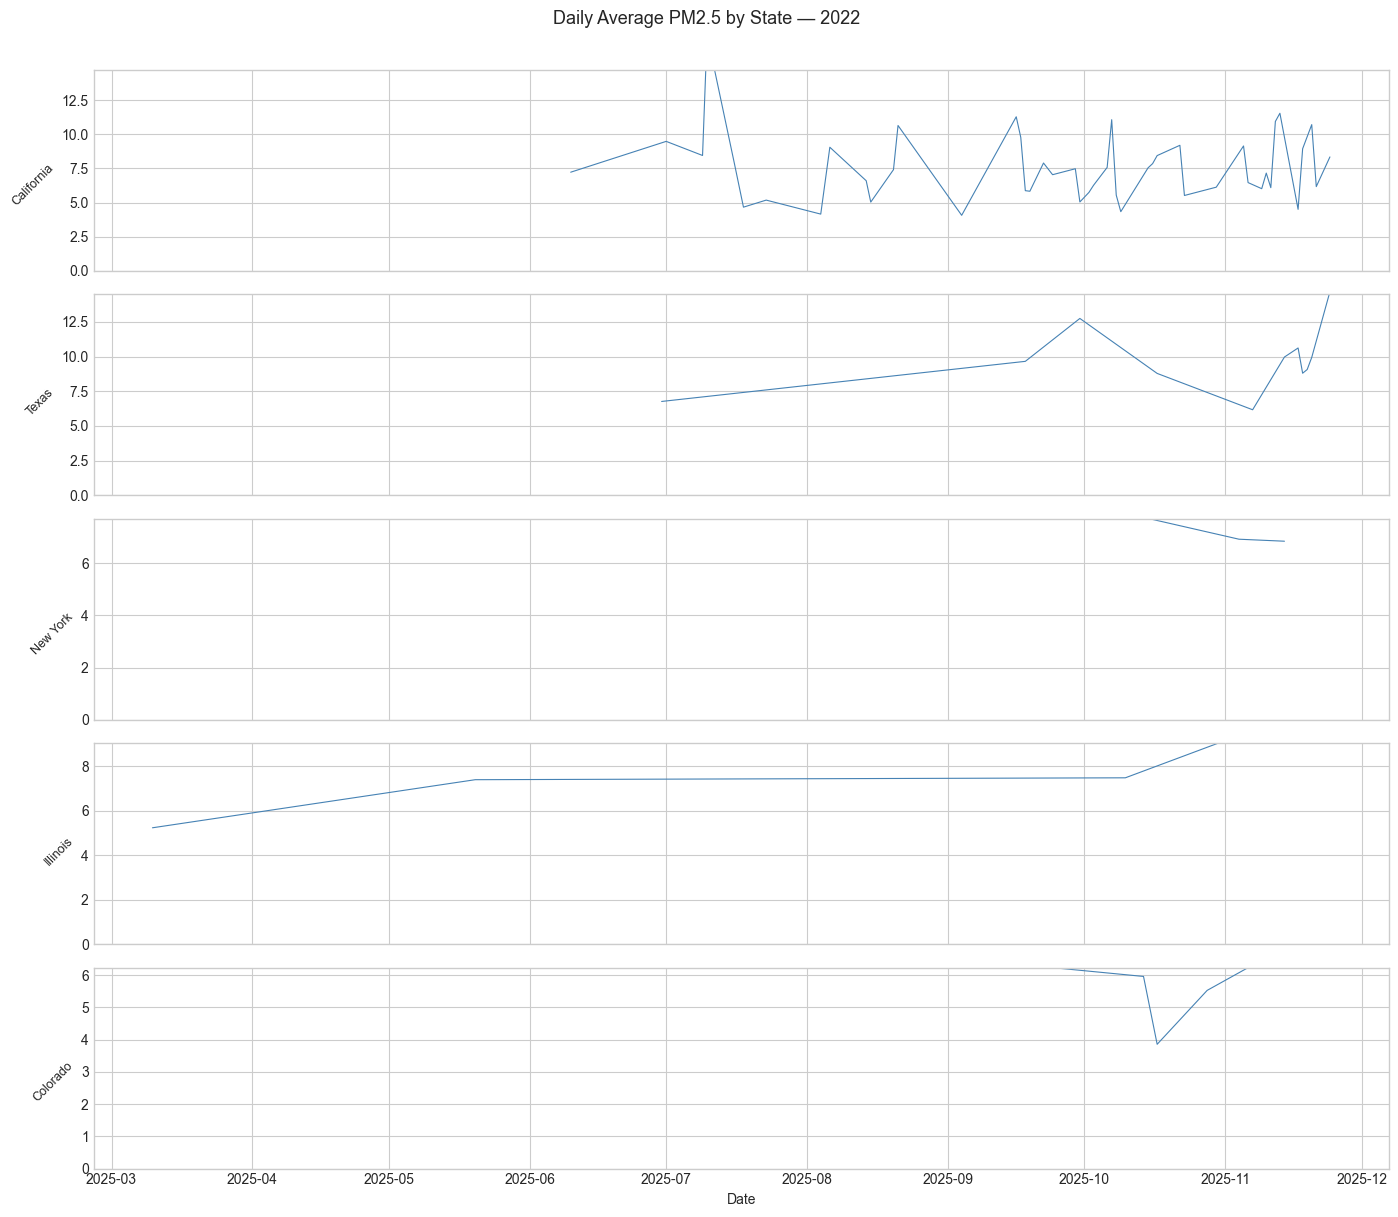

In [11]:
# Cell 11 — Time series plot per state
fig, axes = plt.subplots(len(states_keep), 1, figsize=(14, 12), sharex=True)

for ax, state in zip(axes, states_keep):
    state_data = df_filtered[df_filtered['State Name'] == state]
    daily_avg = state_data.groupby('Date')['PM25'].mean()
    ax.plot(daily_avg.index, daily_avg.values, linewidth=0.8, color='steelblue')
    ax.set_ylabel(state, fontsize=9, rotation=45, ha='right')
    ax.set_ylim(0, daily_avg.quantile(0.99))  # clip outliers for visibility

plt.suptitle('Daily Average PM2.5 by State — 2022', fontsize=13, y=1.01)
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/figures/pm25_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

Pivot shape: (58, 137)
Missing: 7683 cells out of 7946 (96.7%)


<Figure size 1400x600 with 0 Axes>

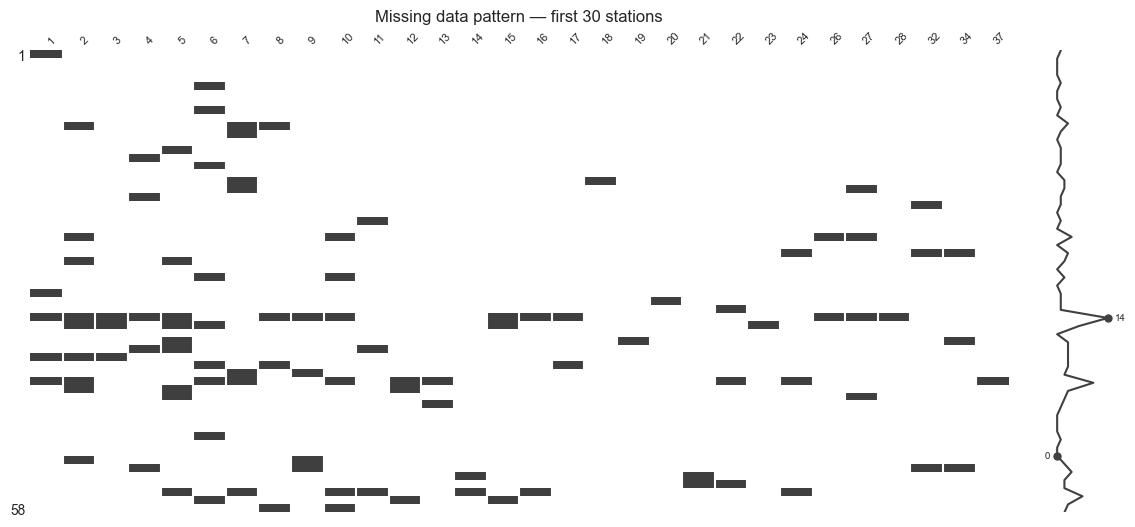

In [12]:
# Cell 12 — Visualize missing data patterns
# Pivot to wide format: rows=dates, cols=stations
pivot = df_filtered.pivot_table(
    index='Date', 
    columns='Site ID', 
    values='PM25'
)

print("Pivot shape:", pivot.shape)
print(f"Missing: {pivot.isna().sum().sum()} cells out of {pivot.size} ({pivot.isna().mean().mean()*100:.1f}%)")

# Missingno matrix — shows WHERE data is missing
plt.figure(figsize=(14, 6))
msno.matrix(pivot.iloc[:, :30], figsize=(14, 6), fontsize=8)  # first 30 stations
plt.title('Missing data pattern — first 30 stations')
plt.tight_layout()
plt.savefig('../outputs/figures/missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 13 — Check for duplicates per station per date
dupes = df.groupby(['Site ID', 'Date']).size()
print("Max rows per station per date:", dupes.max())
print("Mean rows per station per date:", dupes.mean().round(2))
print("\nValue counts:")
print(dupes.value_counts().head())

Max rows per station per date: 3395
Mean rows per station per date: 446.66

Value counts:
362    63
546    47
360    21
542    17
486    17
Name: count, dtype: int64
